# Aq2 / Kq2 — Forward Heat-Flow Model
---
**Pipeline**

```
Input 5 km QRF empirical grid (quantiles)
  |
  +-- STEP 1  Oversampling   5 km -> BedMachine resolution
  |           Bicubic interpolation + per-cell conservative correction
  |
  +-- STEP 2  Volcanic / hydrothermal kernel modification
  |           Multiplicative zero-sum Mexican-hat kernels (log-additive)
  |
  +-- STEP 3  Topographic correction
              Colgan-style with 2-D k_rock / k_ice (Phase 1: constant placeholders)
```

**Conservation invariant:** every step preserves total integrated heat.
Global mean is verified at each stage and stored in NetCDF metadata.

## 1 — Imports and setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

import cmcrameri.cm as cmc
import sys; sys.path.insert(0, str(Path(".").resolve()))
from config import *
from lib.forward import (
    load_empirical_grid, load_volcano_catalogue, load_hydrothermal_catalogue,
    oversample_to_bedmachine, apply_volcanic_kernels,
    topographic_correction, save_forward_product,
)
from lib.uncertainty import compute_uncertainty_summary

print("Imports OK")

✓ config.py v4.0 | obs_model: 21 | obs_sweep: 22 | obs: 36
Imports OK


## 2 — Configuration

In [2]:
with open("forward_params.yaml") as f:
    FP = yaml.safe_load(f)

REGION    = FP["region"]
CHUNKS    = FP["oversampling"]["dask_chunks"]
FINAL_DIR = Path(FP["output"]["final_dir"])
TEMP_DIR  = Path(FP["output"]["temp_dir"])
TEMP_DIR.mkdir(parents=True, exist_ok=True)
FINAL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Region  : {REGION}")
print(f"Temp    : {TEMP_DIR}")
print(f"Output  : {FINAL_DIR}")

Region  : antarctica
Temp    : temp
Output  : output


In [3]:
if REGION == "antarctica":
    BM_FILE    = bedmachine_antarctica_file
    INPUT_NC   = targets_dir / "Aq1_5_QRF_v0_3.nc"
    REGION_CRS = ant_crs
    OUTPUT_NC  = FINAL_DIR / FP["output"]["ant_forward_nc"]
    CACHE_S1   = TEMP_DIR  / FP["output"]["cache_step1_ant"]
    CACHE_S2   = TEMP_DIR  / FP["output"]["cache_step2_ant"]
else:
    BM_FILE    = bedmachine_greenland_file
    INPUT_NC   = targets_dir / "Kq1_5_QRF_v0_3.nc"
    REGION_CRS = grl_crs
    OUTPUT_NC  = FINAL_DIR / FP["output"]["grl_forward_nc"]
    CACHE_S1   = TEMP_DIR  / FP["output"]["cache_step1_grl"]
    CACHE_S2   = TEMP_DIR  / FP["output"]["cache_step2_grl"]

bedmachine   = xr.open_dataset(BM_FILE, chunks=CHUNKS)
FINE_SPACING = float(bedmachine.attrs.get("spacing", 500.0))
print(f"BedMachine: spacing={FINE_SPACING:.0f} m")
print(bedmachine)

BedMachine: spacing=500 m
<xarray.Dataset> Size: 4GB
Dimensions:    (y: 13333, x: 13333)
Coordinates:
  * y          (y) int32 53kB 3333000 3332500 3332000 ... -3332500 -3333000
  * x          (x) int32 53kB -3333000 -3332500 -3332000 ... 3332500 3333000
Data variables:
    mapping    |S1 1B ...
    mask       (y, x) int8 178MB dask.array<chunksize=(2000, 2000), meta=np.ndarray>
    firn       (y, x) float32 711MB dask.array<chunksize=(2000, 2000), meta=np.ndarray>
    surface    (y, x) float32 711MB dask.array<chunksize=(2000, 2000), meta=np.ndarray>
    thickness  (y, x) float32 711MB dask.array<chunksize=(2000, 2000), meta=np.ndarray>
    bed        (y, x) float32 711MB dask.array<chunksize=(2000, 2000), meta=np.ndarray>
    errbed     (y, x) float32 711MB dask.array<chunksize=(2000, 2000), meta=np.ndarray>
    source     (y, x) int8 178MB dask.array<chunksize=(2000, 2000), meta=np.ndarray>
    dataid     (y, x) int8 178MB dask.array<chunksize=(2000, 2000), meta=np.ndarray>
    geoi

In [4]:
ds_5km = load_empirical_grid(INPUT_NC, region=REGION, chunks=None)
print(ds_5km)


────────────────────────────────────────────────────────────
  Loading empirical 5 km grid — antarctica
────────────────────────────────────────────────────────────
  Grid: 1334 x 1334 cells
  Global mean q_mean: 55.914 mW/m2
<xarray.Dataset> Size: 121MB
Dimensions:        (y: 1334, x: 1334)
Coordinates:
  * y              (y) float64 11kB -3.332e+06 -3.327e+06 ... 3.333e+06
  * x              (x) float64 11kB -3.333e+06 -3.328e+06 ... 3.332e+06
Data variables: (12/17)
    qrf_q05_raw    (y, x) float32 7MB dask.array<chunksize=(1334, 1334), meta=np.ndarray>
    q_q05          (y, x) float32 7MB dask.array<chunksize=(1334, 1334), meta=np.ndarray>
    qrf_q25_raw    (y, x) float32 7MB dask.array<chunksize=(1334, 1334), meta=np.ndarray>
    q_q25          (y, x) float32 7MB dask.array<chunksize=(1334, 1334), meta=np.ndarray>
    qrf_q50_raw    (y, x) float32 7MB dask.array<chunksize=(1334, 1334), meta=np.ndarray>
    q_q50          (y, x) float32 7MB dask.array<chunksize=(1334, 1334), me

## 3 — Step 1: Oversampling

Bicubic interpolation from 5 km to BedMachine resolution, followed by
per-cell conservative correction.  Each coarse 5 km cell's mean is preserved
exactly on the fine grid.  Global mean is also verified.

No new spatial information is added — this step removes block artefacts only.

In [5]:
def _cache_valid(cache_path, source_path):
    p, s = Path(cache_path), Path(source_path)
    return p.exists() and p.stat().st_mtime > s.stat().st_mtime

if _cache_valid(CACHE_S1, INPUT_NC):
    print(f"Loading Step 1 from cache: {CACHE_S1}")
    ds_step1 = xr.open_dataset(CACHE_S1, chunks=CHUNKS)
else:
    ds_step1 = oversample_to_bedmachine(
        ds_5km         = ds_5km,
        bedmachine     = bedmachine,
        fine_spacing   = FINE_SPACING,
        coarse_spacing = FP["oversampling"]["coarse_spacing_m"],
        mean_tol       = FP["oversampling"]["global_mean_tol"],
    )
    print("Computing oversampled grid ...")
    ds_step1 = ds_step1.compute()
    ds_step1.to_netcdf(CACHE_S1)
    print(f"Cached to {CACHE_S1}")

Loading Step 1 from cache: temp/ant_step1_oversample.nc


ValueError: `dtype` inference failed in `map_blocks`.

Please specify the dtype explicitly using the `dtype` kwarg.

Original error is below:
------------------------
TypeError("nanquantile() got an unexpected keyword argument 'interpolation'")

Traceback:
---------
  File "/Users/toby/miniconda3/envs/geo/lib/python3.12/site-packages/dask/array/core.py", line 469, in apply_infer_dtype
    o = func(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^
  File "/Users/toby/miniconda3/envs/geo/lib/python3.12/site-packages/dask/array/reductions.py", line 1959, in _custom_quantile
    return np.nanquantile(
           ^^^^^^^^^^^^^^^


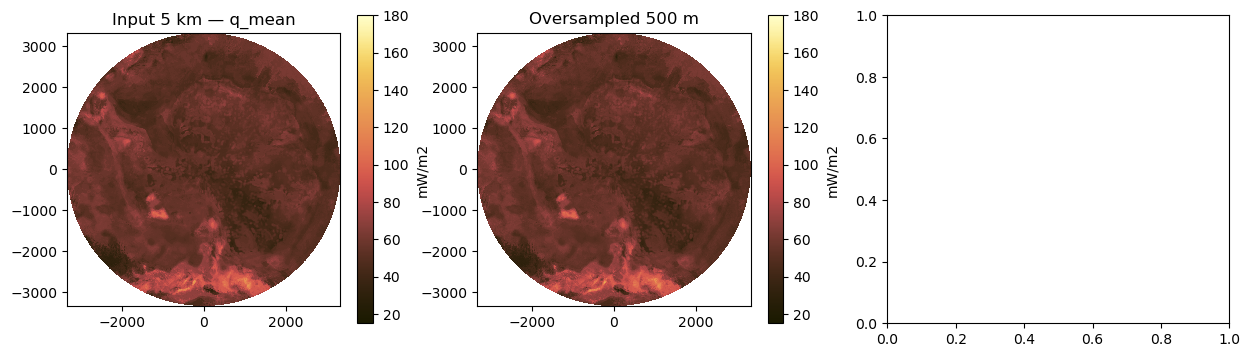

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].pcolormesh(ds_5km.x/1e3, ds_5km.y/1e3, ds_5km["q_mean"]*1e3,
                          cmap=hf_cmap, vmin=hf_v_min, vmax=hf_v_max, rasterized=True)
axes[0].set_title("Input 5 km — q_mean"); axes[0].set_aspect("equal")
plt.colorbar(im0, ax=axes[0], label="mW/m2")

im1 = axes[1].pcolormesh(ds_step1.x/1e3, ds_step1.y/1e3, ds_step1["q_mean"]*1e3,
                          cmap=hf_cmap, vmin=hf_v_min, vmax=hf_v_max, rasterized=True)
axes[1].set_title(f"Oversampled {FINE_SPACING:.0f} m"); axes[1].set_aspect("equal")
plt.colorbar(im1, ax=axes[1], label="mW/m2")

_std_p95 = float(ds_step1["q_std"].quantile(0.95).values)*1e3
im2 = axes[2].pcolormesh(ds_step1.x/1e3, ds_step1.y/1e3, ds_step1["q_std"]*1e3,
                          cmap=unc_cmap, vmin=0, vmax=_std_p95, rasterized=True)
axes[2].set_title("q_std (from QRF quantiles)"); axes[2].set_aspect("equal")
plt.colorbar(im2, ax=axes[2], label="mW/m2")

plt.suptitle(f"Step 1 — Oversampling ({REGION})", y=1.01)
plt.tight_layout()
plt.savefig(fig_root / "forward_step1_oversample.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

for lbl, da in [("5 km input", ds_5km["q_mean"]), ("oversampled", ds_step1["q_mean"])]:
    v = da.values.ravel(); v = v[np.isfinite(v)]*1e3
    print(f"  {lbl:15s}  mean={v.mean():.3f}  std={v.std():.3f}  "
          f"min={v.min():.3f}  max={v.max():.3f}  mW/m2")

## 4 — Step 2: Volcanic / Hydrothermal Kernels

A multiplicative Mexican-hat (difference-of-Gaussians) kernel is placed at
each source via FFT convolution.  Kernels combine log-additively.

The total multiplier field is normalised over ice cells so its mean equals 1.0
— no net heat is created or destroyed.

Kernel classes: `active_volcano`, `pleistocene_volcano`.
(`hydrothermal` for Greenland — placeholder CSV path set in yaml.)

**Uncertainty:** variance inflated in quadrature using kernel amplitude
uncertainty (sigma_factor) and feature-existence probability (p_exists).
Both are currently global placeholders; per-feature override via catalogue
columns is supported (Phase 2).

In [ ]:
vp = FP["volcanic"]
catalogue = load_volcano_catalogue(
    volc_list_path   = vp["volc_list_path"],
    holocene_path    = vp["holocene_path"],
    pleistocene_path = vp["pleistocene_path"],
)
# Greenland: uncomment when vent catalogue is ready
# vent_cat  = load_hydrothermal_catalogue(FP["hydrothermal"]["catalogue_csv"])
# catalogue = pd.concat([catalogue, vent_cat], ignore_index=True)
print(catalogue[["lat","lon","kernel_class","group"]].head(10))

In [ ]:
kernel_params = {
    **{k: v for k, v in vp["kernel_classes"].items()},
    "default_p_exists":     vp["default_p_exists"],
    "default_sigma_factor": vp["default_sigma_factor"],
}

if _cache_valid(CACHE_S2, CACHE_S1):
    print(f"Loading Step 2 from cache: {CACHE_S2}")
    ds_step2 = xr.open_dataset(CACHE_S2, chunks=CHUNKS)
else:
    ds_step2 = apply_volcanic_kernels(
        ds=ds_step1, catalogue=catalogue, kernel_params=kernel_params,
        bedmachine=bedmachine, region_crs=REGION_CRS, fine_spacing=FINE_SPACING,
        mean_tol=FP["oversampling"]["global_mean_tol"],
    )
    ds_step2 = ds_step2.compute()
    ds_step2.to_netcdf(CACHE_S2)
    print(f"Cached to {CACHE_S2}")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
_dv_max = float(np.abs(ds_step2["delta_volc"].values).max())*1e3

im0 = axes[0].pcolormesh(ds_step2.x/1e3, ds_step2.y/1e3, ds_step2["volc_multiplier"],
                          cmap="RdBu_r", vmin=0.9, vmax=1.1, rasterized=True)
axes[0].set_title("Volcanic multiplier M"); axes[0].set_aspect("equal")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(ds_step2.x/1e3, ds_step2.y/1e3, ds_step2["delta_volc"]*1e3,
                          cmap="RdBu_r", vmin=-_dv_max, vmax=_dv_max, rasterized=True)
axes[1].set_title("Delta_q_volc [mW/m2]"); axes[1].set_aspect("equal")
plt.colorbar(im1, ax=axes[1], label="mW/m2")

_inf_max = float(np.nanpercentile(ds_step2["volc_inflate_factor"].values, 99.9))
im2 = axes[2].pcolormesh(ds_step2.x/1e3, ds_step2.y/1e3, ds_step2["volc_inflate_factor"],
                          cmap="YlOrRd", vmin=1, vmax=_inf_max, rasterized=True)
axes[2].set_title("Uncertainty inflation factor"); axes[2].set_aspect("equal")
plt.colorbar(im2, ax=axes[2])

plt.suptitle(f"Step 2 — Volcanic kernels ({REGION})", y=1.01)
plt.tight_layout()
plt.savefig(fig_root / "forward_step2_volcanic.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

## 5 — Step 3: Topographic Correction

Colgan-style correction using BedMachine bed/surface topography.

$$\Delta G_{\text{bed}}  = q \cdot \frac{k_{\text{rock}}}{k_{\text{ref}}} \cdot \frac{z_{\text{bed}} - \bar{z}_{\text{bed}}}{r}$$

$$\Delta G_{\text{ice}}  = q \cdot \frac{k_{\text{ice}}}{k_{\text{ref}}} \cdot \frac{z_{\text{surf}} - z_{\text{bed}}}{r}$$

**Phase 1:** spatially constant $k_{\text{rock}}=1.8$ and $k_{\text{ice}}=2.1$ W m$^{-1}$ K$^{-1}$.

**BedMachine coverage:** correction applied only where direct observations exist.
Ocean cells use $k_{\text{ocean}}=6.0$ W m$^{-1}$ K$^{-1}$ (placeholder).
Submarine correction is **not implemented** — noted in NetCDF attributes.

In [ ]:
tp = FP["topo_correction"]

# Phase 1 placeholders — spatially constant
# Phase 2: replace with xr.open_dataarray("data/k_rock_geology.nc") etc.
k_rock = xr.full_like(ds_step2["q_mean"], fill_value=tp["k_rock_default"], dtype=np.float32)
k_ice  = xr.full_like(ds_step2["q_mean"], fill_value=tp["k_ice_default"],  dtype=np.float32)
k_rock.attrs = {"units": "W m-1 K-1",
                "long_name": "Rock conductivity (Phase 1: constant placeholder)",
                "phase": "1"}
k_ice.attrs  = {"units": "W m-1 K-1",
                "long_name": "Ice conductivity (Phase 1: constant placeholder)",
                "phase": "1 — Phase 2: temperature-dependent k_ice(T_b)"}
k_rock_std = k_ice_std = None   # Phase 2: supply spatially varying std arrays

print(f"k_rock = {tp['k_rock_default']} W/m/K  (Phase 1 placeholder)")
print(f"k_ice  = {tp['k_ice_default']} W/m/K  (Phase 1 placeholder)")

In [ ]:
ds_step3 = topographic_correction(
    ds           = ds_step2,
    bedmachine   = bedmachine,
    k_rock       = k_rock,
    k_ice        = k_ice,
    k_rock_std   = k_rock_std,
    k_ice_std    = k_ice_std,
    r_m          = tp["r_m"],
    k_ref        = tp["k_ref"],
    k_ocean      = tp["k_ocean"],
    clip_max     = tp["clip_max_Wm2"],
    apply_only_where_covered = tp["apply_only_where_bedmachine_direct"],
    fine_spacing = FINE_SPACING,
)
ds_step3 = ds_step3.compute()
print("Topographic correction complete")

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
_panels = [
    (axes[0,0], ds_step3["delta_G_bed"]*1e3,   "DeltaG_bed [mW/m2]",  "RdBu_r"),
    (axes[0,1], ds_step3["delta_G_ice"]*1e3,   "DeltaG_ice [mW/m2]",  "RdBu_r"),
    (axes[0,2], ds_step3["delta_topo"]*1e3,    "DeltaG_total [mW/m2]","RdBu_r"),
    (axes[1,0], ds_step3["q_mean"]*1e3,        "q_mean post-topo",    hf_cmap),
    (axes[1,1], ds_step3["delta_topo_std"]*1e3,"DeltaG uncertainty",   unc_cmap),
    (axes[1,2], ds_step3["q_std"]*1e3,         "q_std (cumulative)",   unc_cmap),
]
for ax, da, title, cmap in _panels:
    vals = da.values
    vmax = float(np.nanpercentile(np.abs(vals[np.isfinite(vals)]), 99))
    vmin = -vmax if cmap == "RdBu_r" else 0
    im = ax.pcolormesh(ds_step3.x/1e3, ds_step3.y/1e3, vals,
                       cmap=cmap, vmin=vmin, vmax=vmax, rasterized=True)
    ax.set_title(title, fontsize=9); ax.set_aspect("equal")
    plt.colorbar(im, ax=ax, shrink=0.8, label="mW/m2")

plt.suptitle(f"Step 3 — Topographic correction ({REGION})", y=1.01)
plt.tight_layout()
plt.savefig(fig_root / "forward_step3_topo.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

## 6 — Uncertainty Summary

In [ ]:
ds_final = compute_uncertainty_summary(ds_step3)
unc_vars = [v for v in ds_final.data_vars if any(s in v for s in ("std","iqr","cv","ci90"))]
print("Uncertainty fields:", unc_vars)

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
_unc_p = [
    (axes[0,0], ds_final["q_mean"]*1e3,       "q_mean [mW/m2]",       hf_cmap, (hf_v_min, hf_v_max)),
    (axes[0,1], ds_final["q_std"]*1e3,        "q_std [mW/m2]",        unc_cmap, None),
    (axes[0,2], ds_final["q_cv"]*100,         "CV = sigma/mu [%]",    "plasma", (0, 50)),
    (axes[1,0], ds_final["q_iqr"]*1e3,        "IQR (q25-q75) [mW/m2]",unc_cmap, None),
    (axes[1,1], ds_final["q_ci90_lower"]*1e3, "q_05 [mW/m2]",         hf_cmap, (hf_v_min, hf_v_max)),
    (axes[1,2], ds_final["q_ci90_upper"]*1e3, "q_95 [mW/m2]",         hf_cmap, (hf_v_min, hf_v_max)),
]
for ax, da, title, cmap, vlims in _unc_p:
    vals = da.values
    if vlims is None:
        vmax = float(np.nanpercentile(vals[np.isfinite(vals)], 98))
        vlims = (0, vmax)
    im = ax.pcolormesh(ds_final.x/1e3, ds_final.y/1e3, vals,
                       cmap=cmap, vmin=vlims[0], vmax=vlims[1], rasterized=True)
    ax.set_title(title, fontsize=9); ax.set_aspect("equal")
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle(f"Uncertainty summary ({REGION})", y=1.01)
plt.tight_layout()
plt.savefig(fig_root / "forward_uncertainty_summary.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

In [ ]:
mask_ice = (ds_final["mask"].values > 0).ravel()
rows = {}
for var in ["q_mean","q_std","q_iqr","delta_volc","delta_topo","delta_topo_std"]:
    if var not in ds_final: continue
    v = ds_final[var].values.ravel()
    v = v[mask_ice & np.isfinite(v)] * 1e3
    rows[var] = dict(mean=v.mean(), median=float(np.median(v)), std=v.std(),
                     p05=float(np.percentile(v,5)), p95=float(np.percentile(v,95)))
budget = pd.DataFrame(rows).T
budget.columns = ["mean","median","std","p05","p95"]
print("\nUncertainty budget (mW/m2, ice cells only):")
print(budget.round(3).to_string())

In [ ]:
high_unc_threshold = 0.50
high_unc = ds_final["q_cv"] > high_unc_threshold
n_high = int(high_unc.sum().values)
n_ice  = int(mask_ice.sum())
print(f"Cells with CV > {high_unc_threshold*100:.0f}%: "
      f"{n_high:,} / {n_ice:,} ({n_high/n_ice*100:.1f}%)")

## 7 — Save Outputs

In [ ]:
save_forward_product(
    ds=ds_final, out_path=OUTPUT_NC, region=REGION,
    model_version=MODEL_VERSION,
    compression_level=FP["output"]["compression_level"],
    author=NETCDF_AUTHOR,
)
print(f"\nFinal product: {OUTPUT_NC}")

In [ ]:
ds_check = xr.open_dataset(OUTPUT_NC)
print(ds_check)
print("\nGlobal attributes:")
for k, v in ds_check.attrs.items():
    print(f"  {k}: {v}")
ds_check.close()

## 8 — Paper Figures

Manuscript-quality figures generated from the saved NetCDF.
These cells are independent of Sections 3-7 and can be re-run
after loading the saved product without repeating the pipeline.

In [ ]:
ds_pub = xr.open_dataset(OUTPUT_NC)
print(f"Loaded {OUTPUT_NC}  ({Path(OUTPUT_NC).stat().st_size/1e6:.1f} MB)")

In [ ]:
# Main heat-flow map
fig, ax = plt.subplots(figsize=(MAP_W_ANT*1.5, MAP_H_ANT*1.5))
im = ax.pcolormesh(ds_pub.x/1e3, ds_pub.y/1e3, ds_pub["q_mean"]*1e3,
                   cmap=hf_cmap, vmin=hf_v_min, vmax=hf_v_max, rasterized=True)
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.03)
cbar.set_label(f"Heat flow ({hf_unit})", fontsize=10)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)"); ax.set_ylabel("Northing (km)")
ax.set_title(f"Geothermal heat flow — {REGION.capitalize()}")
plt.tight_layout()
plt.savefig(fig_root / f"paper_hf_mean_{REGION}.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Uncertainty triptych
fig, axes = plt.subplots(1, 3, figsize=(MAP_W_ANT*4, MAP_H_ANT*1.2))
for ax, var, title, cmap in [
    (axes[0], "q_std",  "sigma [mW/m2]",           unc_cmap),
    (axes[1], "q_cv",   "CV = sigma/mu [%]",        "plasma"),
    (axes[2], "q_iqr",  "IQR q25-q75 [mW/m2]",     unc_cmap),
]:
    mult = 100 if var == "q_cv" else 1e3
    vals = ds_pub[var].values * mult
    vmax = float(np.nanpercentile(vals[np.isfinite(vals)], 98))
    im = ax.pcolormesh(ds_pub.x/1e3, ds_pub.y/1e3, vals,
                       cmap=cmap, vmin=0, vmax=vmax, rasterized=True)
    ax.set_aspect("equal"); ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.85, label="%" if var=="q_cv" else "mW/m2")
plt.suptitle(f"Uncertainty — {REGION.capitalize()}", y=1.01)
plt.tight_layout()
plt.savefig(fig_root / f"paper_uncertainty_{REGION}.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Correction fields
fig, axes = plt.subplots(1, 2, figsize=(MAP_W_ANT*2.5, MAP_H_ANT*1.2))
for ax, var, title in [
    (axes[0], "delta_volc",  "Volcanic correction [mW/m2]"),
    (axes[1], "delta_topo",  "Topographic correction [mW/m2]"),
]:
    vals = ds_pub[var].values * 1e3
    vmax = float(np.nanpercentile(np.abs(vals[np.isfinite(vals)]), 99))
    im = ax.pcolormesh(ds_pub.x/1e3, ds_pub.y/1e3, vals,
                       cmap="RdBu_r", vmin=-vmax, vmax=vmax, rasterized=True)
    ax.set_aspect("equal"); ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.85, label="mW/m2")
plt.tight_layout()
plt.savefig(fig_root / f"paper_corrections_{REGION}.png", dpi=300, bbox_inches="tight")
plt.show()